In [1]:
import sklearn
print(sklearn.__version__)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Other plots (example)

from src.exp import (
    ExperimentConfig, ExperimentFacade,
    DataReadConfig, PlotManager
)

1.8.0


In [2]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel sklearn patch enabled")
except ImportError:
    print("sklearnex not installed; using standard sklearn")


sklearnex not installed; using standard sklearn


In [3]:
data_cfg = DataReadConfig(
    root_dir="Dataset/data",
    recursive=True,
    exclude_filenames=["cclass.csv", "unclean focus.csv","unclean cclass.csv","focus.csv"],  # the excluded files
    add_source_column=False,        # enable this to make additional column filled with the original taken filenames
)

In [4]:
cfg = ExperimentConfig(
    outer_folds=5,
    inner_folds=5,
    n_trials=40,
    seed=42,
    log_target=True
)

In [5]:
models = ["XGBoost"] #["LinearRegression", "DecisionTree", "RandomForest", "SVR", "XGBoost", "NeuralNetwork"]

In [6]:
exp = ExperimentFacade.from_folder(
    data_cfg=data_cfg,
    target="price",
    cfg=cfg,
    model_names=models,
    hparam_json="config/hyperparams.json"
)

# model, year, price, transmission, mileage, fuelType, tax, mpg, engineSize

[schema]
  numerical cols: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
  categorical cols: ['model', 'transmission', 'fuelType']
  target col: ['price']
  mapping: {'model': 'model', 'year': 'year', 'price': 'price', 'transmission': 'transmission', 'mileage': 'mileage', 'fuelType': 'fuelType', 'tax': 'tax', 'mpg': 'mpg', 'engineSize': 'engineSize'}


In [7]:
results = exp.run()

[I 2026-02-05 05:40:05,651] A new study created in memory with name: XGBoost_OuterFold_1_residual_cfg_Huber
[I 2026-02-05 05:40:12,057] Trial 0 finished with value: 0.9583509680324077 and parameters: {'n_estimators': 391, 'max_depth': 8, 'min_child_weight': 6, 'learning_rate': 0.03946258454352426, 'subsample': 0.7538823612176545, 'colsample_bytree': 0.709595722500781, 'reg_alpha': 0.21868150143934234, 'early_stopping_rounds': 91, 'residual__Huber__epsilon': 1.4223593410062134, 'residual__Huber__alpha': 0.013172821939842502}. Best is trial 0 with value: 0.9583509680324077.
[I 2026-02-05 05:40:19,995] Trial 1 finished with value: 0.9561670702526384 and parameters: {'n_estimators': 1278, 'max_depth': 3, 'min_child_weight': 4, 'learning_rate': 0.1855620234064664, 'subsample': 0.7870395602893674, 'colsample_bytree': 0.6560685630600447, 'reg_alpha': 0.00016230911059392133, 'early_stopping_rounds': 151, 'residual__Huber__epsilon': 1.9234082639213395, 'residual__Huber__alpha': 0.04082520602355

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/hyperparameters/best_hyperparameters.json
[final fit] XGBoost
[saved] XGBoost
[saved] XGBoost+Huber
[saved] XGBoost+PseudoHuber
[saved] XGBoost ensemble top3


In [8]:
display(exp.summary())
model_summary = exp.summary()["model"]

,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,XGBoost+Huber,0.961626,0.005846,1131.425846,59.079014,730.827665,36.830840,3.734888e+06,568396.674514,1928.117899,146.837897
1,XGBoost+PseudoHuber,0.964017,0.003518,1088.016873,13.688472,702.116992,9.703517,3.501023e+06,329065.145556,1869.402749,89.137293


In [22]:
model_summary.to_list()

['XGBoost+Huber', 'XGBoost+PseudoHuber']

In [10]:
sig = exp.significance(
    metric="R2",
    baseline="XGBoost+PseudoHuber",
    models=["XGBoost+Huber", "XGBoost+PseudoHuber"]
)

In [11]:
display(sig)

,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
0,R2,XGBoost+PseudoHuber,XGBoost+Huber,0.125358,0.1875,5


In [23]:
shap_analyzer = exp.shap(models=model_summary.to_list())

In [24]:
shap_analyzer.available_models()

['XGBoost', 'XGBoost+Huber', 'XGBoost+PseudoHuber']

XGBoost


Computing SHAP for XGBoost:   0%|          | 0/10 [00:00<?, ?it/s]

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_xgboost.png


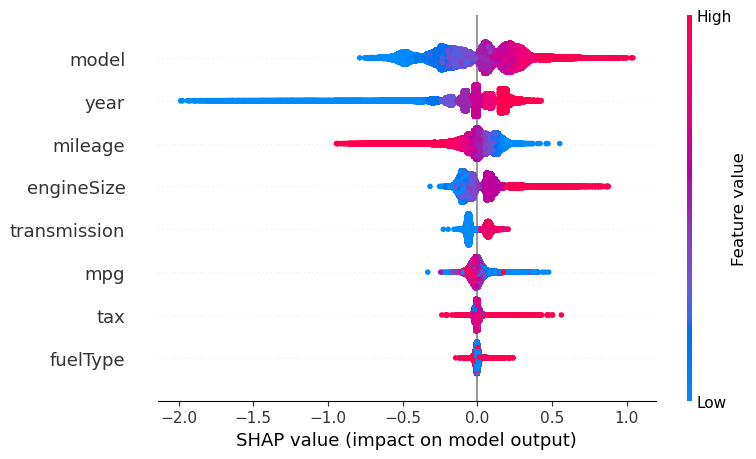

XGBoost+Huber


Computing SHAP for XGBoost+Huber:   0%|          | 0/5 [00:00<?, ?it/s]

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_xgboost+huber.png


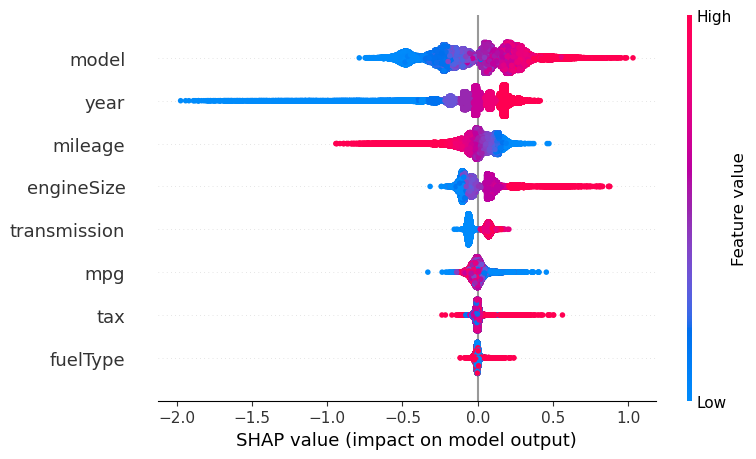

XGBoost+PseudoHuber


Computing SHAP for XGBoost+PseudoHuber:   0%|          | 0/5 [00:00<?, ?it/s]

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_xgboost+pseudohuber.png


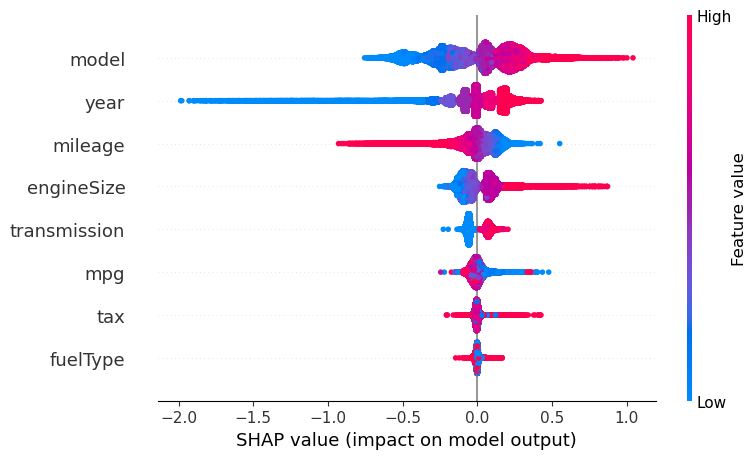

In [25]:
for m in shap_analyzer.available_models():
    shap_analyzer.beeswarm(m)

In [15]:
exp.summary()

,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,XGBoost+Huber,0.961626,0.005846,1131.425846,59.079014,730.827665,36.830840,3.734888e+06,568396.674514,1928.117899,146.837897
1,XGBoost+PseudoHuber,0.964017,0.003518,1088.016873,13.688472,702.116992,9.703517,3.501023e+06,329065.145556,1869.402749,89.137293


In [16]:
results.to_csv("outputs/experiment_results.csv", index=False)

In [17]:
pm = PlotManager("outputs/figures/metrics")

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_r2.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_mae.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_medae.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_mse.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_rmse.png


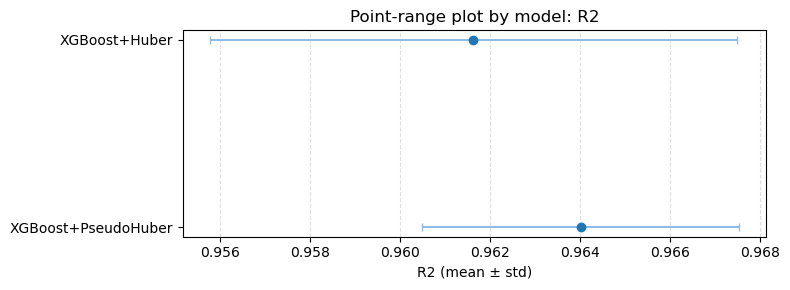

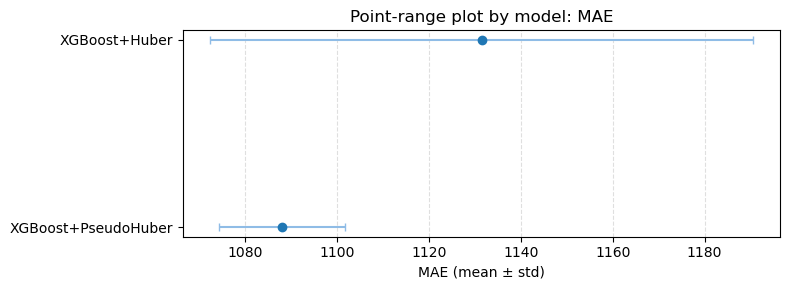

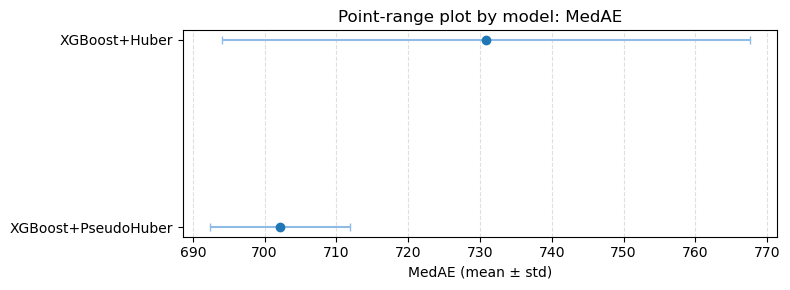

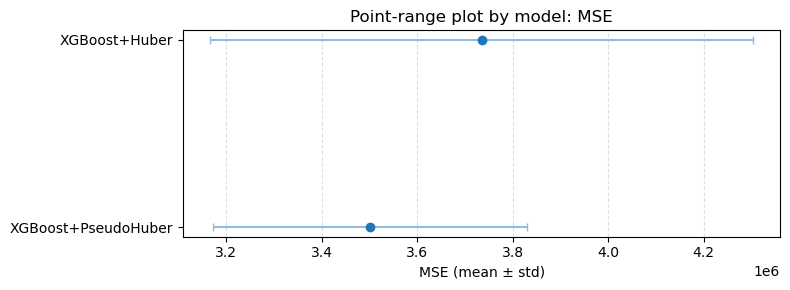

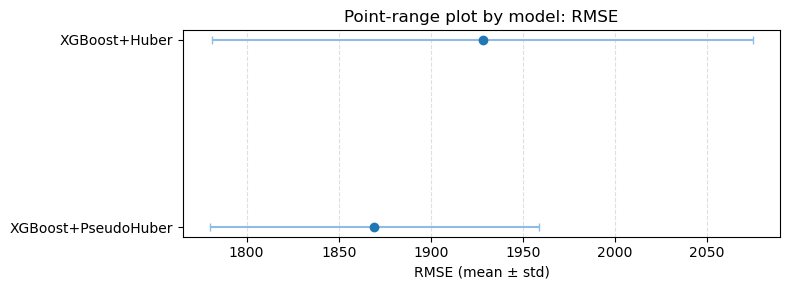

In [18]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    is_ascending = metric != "R2" and metric != "NegMSE"
    #fig = plot_point_range_1(results, metric=metric, ascending=is_ascending)
    #fig.savefig(f"outputs/figures/metrics/point_range_{metric.lower()}", dpi=300, bbox_inches="tight")
    fig = pm.plot_point_range(results_df=results, metric=metric, ascending=is_ascending)
    pm.save_fig(fig, f"point_range_{metric.lower()}")

In [19]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    display(exp.significance_matrix(metric=metric))

,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,R2,XGBoost+Huber,XGBoost+PseudoHuber,0.125358,0.1875,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,MAE,XGBoost+Huber,XGBoost+PseudoHuber,0.14421,0.125,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,MedAE,XGBoost+Huber,XGBoost+PseudoHuber,0.191325,0.125,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,MSE,XGBoost+Huber,XGBoost+PseudoHuber,0.122288,0.1875,5


,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,RMSE,XGBoost+Huber,XGBoost+PseudoHuber,0.115646,0.1875,5


In [20]:
exp.save_best_params()

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/best_params/best_params.json
